In [3]:
from utils import variables, functions

# realod them (maybe have been updated)
import importlib
importlib.reload(functions)
importlib.reload(variables)

import pickle, os, json, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from IPython.display import clear_output

Functions imported correctly.
Variables imported correctly.


Run this in the terminal:

In [4]:
#!pip install datalad --break-system-packages

In [11]:
# GET DATA
%cd /workspace/devcontainer-bigdata/

# Configure Git
!git config --global user.name "ctomasoni5"
!git config --global user.email "c.tomasoni5@campus.unimib.it"

# Clone data in a temporary directory
!datalad clone https://github.com/OpenNeuroDatasets/ds001499 /tmp/ds001499

# Get events and confounds files
%cd /tmp/ds001499
!datalad get sub-*/ses-*/func/sub-*_ses-*_task-*_events.tsv

%cd /tmp/ds001499/derivatives/fmriprep
!datalad get sub-*/ses-*/func/sub-*_task-*_confounds.tsv

clear_output()

# Check the folder with data
!ls -la /tmp/ds001499

total 76
drwxr-xr-x  9 mambauser mambauser 4096 Dec 23 09:16 .
drwxrwxrwt  1 root      root      4096 Dec 23 09:16 ..
-rw-r--r--  1 mambauser mambauser   14 Dec 23 09:16 .bidsignore
drwxr-xr-x  2 mambauser mambauser 4096 Dec 23 09:16 .datalad
drwxr-xr-x  9 mambauser mambauser 4096 Dec 23 09:16 .git
-rw-r--r--  1 mambauser mambauser  284 Dec 23 09:16 .gitattributes
-rw-r--r--  1 mambauser mambauser   44 Dec 23 09:16 CHANGES
-rw-r--r--  1 mambauser mambauser 2833 Dec 23 09:16 README
-rw-r--r--  1 mambauser mambauser 1227 Dec 23 09:16 dataset_description.json
drwxr-xr-x  6 mambauser mambauser 4096 Dec 23 09:16 derivatives
-rw-r--r--  1 mambauser mambauser  119 Dec 23 09:16 participants.tsv
drwxr-xr-x 18 mambauser mambauser 4096 Dec 23 09:16 sub-CSI1
drwxr-xr-x 18 mambauser mambauser 4096 Dec 23 09:16 sub-CSI2
drwxr-xr-x 18 mambauser mambauser 4096 Dec 23 09:16 sub-CSI3
drwxr-xr-x 12 mambauser mambauser 4096 Dec 23 09:16 sub-CSI4
-rw-r--r--  1 mambauser mambauser  131 Dec 23 09:16 task-500

https://github.com/amikelive/coco-labels/blob/master/coco-labels-2014_2017.txt

https://medium.com/data-science/getting-started-with-coco-dataset-82def99fa0b8

The folder BOLD5000_Stimuli in Drive contains 3 files:

- coco_final_annotations.pkl: annotations of the images taken from COCO dataset. Each image contains more than one object, and the file contains the coordinates of the segmentation boxes of all the objects, with the corresponding category.

  Problem: there is not the "semantic class", just the category ID (number).

- imagenet_final_labels.txt: labels of the images taken from ImageNet (one label for image).

  Problem: categories too specific (like types of fishes)

- scene_final_labels.txt: labels of the scene images (one label for image).

##### COCO Labels

In [12]:
# Load the annotations
with open(os.path.join(variables.BOLD5000_PATH,'Image_Labels/coco_final_annotations.pkl'), 'rb') as f:
    coco_annotations = pickle.load(f)

# Pickle file structure
print(".pkl file structure:")
print(f"Type: {type(coco_annotations)}")
if isinstance(coco_annotations, dict):
    sample_key = list(coco_annotations.keys())[0]
    print(f"Key example: {sample_key}")
    print(f"Value example: {coco_annotations[sample_key]}\n")


category_ids = sorted({ ann['category_id']
                        for ann_list in coco_annotations.values()
                        for ann in ann_list })

# Count the categories
coco_categories = {}
for image_id, annotations in coco_annotations.items():
    for annotation in annotations:
        category_id = annotation['category_id']
        if category_id not in coco_categories:
            coco_categories[category_id] = 1
        else:
            coco_categories[category_id] += 1

print(f"Number of categories: {len(coco_categories)}")
print(coco_categories)
print(f"Min category: {min(coco_categories.keys())}")
print(f"Max category: {max(coco_categories.keys())}")

.pkl file structure:
Type: <class 'dict'>
Key example: 262145
Value example: [{'segmentation': [[214.27, 79.01, 220.54, 82.35, 235.99, 91.54, 247.69, 97.39, 255.2, 101.15, 265.64, 109.08, 261.89, 98.22, 256.04, 86.53, 248.94, 79.85, 244.76, 74.0, 237.66, 67.73, 232.23, 65.65, 228.89, 63.56, 231.4, 55.62, 229.31, 56.04, 226.38, 62.72, 220.12, 60.63, 215.94, 60.63, 214.27, 61.05, 218.87, 66.06, 216.36, 70.66, 212.6, 75.67, 212.6, 78.59]], 'area': 970.0430999999998, 'iscrowd': 0, 'image_id': 262145, 'bbox': [212.6, 55.62, 53.04, 53.46], 'category_id': 28, 'id': 284647}, {'segmentation': [[35.5, 1.76, 13.43, 16.15, 47.02, 19.03, 113.23, 24.79, 172.72, 47.82, 182.31, 51.66, 205.34, 56.45, 226.45, 56.45, 239.89, 57.41, 202.47, 3.68]], 'area': 6085.1964499999995, 'iscrowd': 0, 'image_id': 262145, 'bbox': [13.43, 1.76, 226.46, 55.65], 'category_id': 28, 'id': 285569}, {'segmentation': [[278.13, 265.47, 289.68, 284.8, 295.45, 285.96, 297.18, 281.63, 279.58, 260.56, 278.42, 262.58]], 'area': 164

In [13]:
import urllib.request
import zipfile

%cd /workspace/devcontainer-bigdata/

# Download the file with the labels associated to the categories id
url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
urllib.request.urlretrieve(url, "annotations_trainval2017.zip")

# Decompress
with zipfile.ZipFile("annotations_trainval2017.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

/workspace/devcontainer-bigdata


In [14]:
# Load annotations
with open("annotations/instances_val2017.json", "r") as f:
    coco_json = json.load(f)

# Extract official COCO label names
id2name_partial = {c['id']: c['name'] for c in coco_json['categories']}
coco_id2name = {i: id2name_partial.get(i) for i in range(0, 91)}
coco_id2name[0] = "background"

# Display the labels
for cid, name in coco_id2name.items():
    print(f"{cid:2d}: {name}")
print(f'Number of labels of COCO: {len(coco_id2name)}')

 0: background
 1: person
 2: bicycle
 3: car
 4: motorcycle
 5: airplane
 6: bus
 7: train
 8: truck
 9: boat
10: traffic light
11: fire hydrant
12: None
13: stop sign
14: parking meter
15: bench
16: bird
17: cat
18: dog
19: horse
20: sheep
21: cow
22: elephant
23: bear
24: zebra
25: giraffe
26: None
27: backpack
28: umbrella
29: None
30: None
31: handbag
32: tie
33: suitcase
34: frisbee
35: skis
36: snowboard
37: sports ball
38: kite
39: baseball bat
40: baseball glove
41: skateboard
42: surfboard
43: tennis racket
44: bottle
45: None
46: wine glass
47: cup
48: fork
49: knife
50: spoon
51: bowl
52: banana
53: apple
54: sandwich
55: orange
56: broccoli
57: carrot
58: hot dog
59: pizza
60: donut
61: cake
62: chair
63: couch
64: potted plant
65: bed
66: None
67: dining table
68: None
69: None
70: toilet
71: None
72: tv
73: laptop
74: mouse
75: remote
76: keyboard
77: cell phone
78: microwave
79: oven
80: toaster
81: sink
82: refrigerator
83: None
84: book
85: clock
86: vase
87: scissors

In [15]:
# create a dataframe
coco_final_labels_df = pd.DataFrame({
    "category_id": category_ids,
    "official_name": [ coco_id2name.get(i, pd.NA) for i in category_ids ]
})
coco_final_labels_df.head(5)

,category_id,official_name
0,1,person
1,2,bicycle
2,3,car
3,4,motorcycle
4,5,airplane


In [16]:
# check if there are NaN in the df
coco_final_labels_df.isna().sum()

category_id      0
official_name    0
dtype: int64

In [17]:
# Example of image
# In the BOLD5000_Stimuli there are two folders: original images, and presented images 
# (same content but processed, maybe cut and resized)
original_coco_images_path = os.path.join(variables.BOLD5000_PATH,'Scene_Stimuli/Original_Images/COCO')
presented_coco_images_path = os.path.join(variables.BOLD5000_PATH,'Scene_Stimuli/Presented_Stimuli/COCO')

print(f"Number of COCO images in Original_Images: {len(os.listdir(original_coco_images_path))}")
print(f"Number of COCO images in Presented_Images: {len(os.listdir(presented_coco_images_path))}")

original_coco_images = sorted(os.listdir(original_coco_images_path))
presented_coco_images = sorted(os.listdir(presented_coco_images_path))

Number of COCO images in Original_Images: 2000
Number of COCO images in Presented_Images: 2000


In [18]:
coco_image_to_category = {
    image_id: [ann["category_id"] for ann in anns]
    for image_id, anns in coco_annotations.items()
}

# Print first keys as example
for k, v in list(coco_image_to_category.items())[:5]:
    print(k, "→", v)

print("\n")

# Analyze the quantity of labels per image
# store in a dictionary, the name of the image and the amount of labels in it
labels_per_image = {}
for image_id, labels in coco_image_to_category.items():
    labels_per_image[image_id] = len(labels)
# print 5
for idx, (image_id, count) in enumerate(labels_per_image.items()):
    if idx >= 5:
        break
    print(f"Image {image_id}: {count} labels")

262145 → [28, 28, 57, 57, 57, 57, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 28, 57, 57, 57, 57, 57, 57, 57, 57, 1, 28, 57, 1, 57]
106498 → [85, 85]
460118 → [20, 20, 20, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
204806 → [23]
368647 → [65, 62, 62, 67]


Image 262145: 32 labels
Image 106498: 2 labels
Image 460118: 13 labels
Image 204806: 1 labels
Image 368647: 4 labels


In [19]:
# Count types of labels
labels_type_count = {}

for image_id, labels in coco_image_to_category.items():
    unique_labels = set(labels)              # take only unique categories
    labels_type_count[image_id] = len(unique_labels)

# Print first 5
for idx, (image_id, count) in enumerate(labels_type_count.items()):
    if idx >= 5:
        break
    print(f"Image {image_id}: {count} unique label types")

Image 262145: 3 unique label types
Image 106498: 1 unique label types
Image 460118: 2 unique label types
Image 204806: 1 unique label types
Image 368647: 3 unique label types


Idx: 1897
Image index 1897 in Original_Images: COCO_train2014_000000552589.jpg
Image index 1897 in Presented_Images: COCO_train2014_000000552589.jpg
Image ID: 552589

Found: 1 objects in image: 552589

Oggetto 1:
  - Category ID: 25
  - Area: 41553.87105
  - Bbox: [214.29, 182.65, 231.55, 448.72]
  - Class Name: giraffe




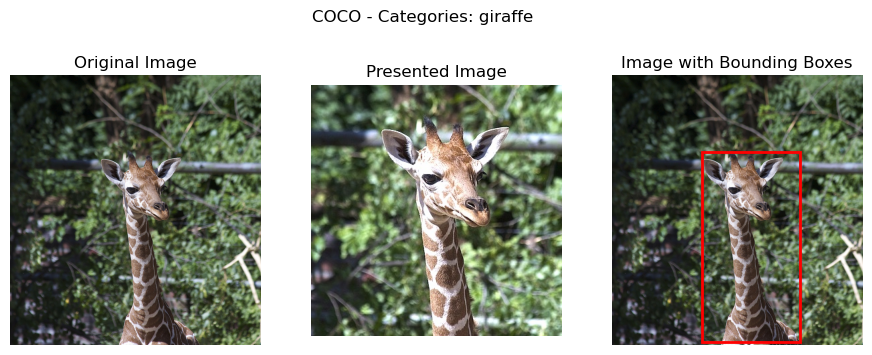

In [20]:
import random

# FInd a random index 
idx = random.randint(0, len(original_coco_images) - 1)
print(f'Idx: {idx}')

# Find the name of the image corresponding to that index
image_name = original_coco_images[idx]

functions.show_coco_images(idx, original_coco_images, presented_coco_images, coco_annotations, original_coco_images_path, presented_coco_images_path, coco_final_labels_df)

In [21]:
# convert coco_image_to_category to a dataframe with: image_name, number of labels, list of labels, number of type of labels
coco_image_to_category_df = pd.DataFrame()
coco_image_to_category_df['image_name'] = coco_image_to_category.keys()
coco_image_to_category_df['number_labels'] = labels_per_image.values()
coco_image_to_category_df['list_labels'] = coco_image_to_category.values()
coco_image_to_category_df['number_type_labels'] = labels_type_count.values()
coco_image_to_category_df.head(5)

,image_name,number_labels,list_labels,number_type_labels
0,262145,32,"[28, 28, 57, 57, 57, 57, 1, 1, 1, 1, 1, 1, 1, ...",3
1,106498,2,"[85, 85]",1
2,460118,13,"[20, 20, 20, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",2
3,204806,1,[23],1
4,368647,4,"[65, 62, 62, 67]",3


##### ImagNet

In [22]:
# open imagenet_final_labels.txt
with open(os.path.join(variables.BOLD5000_PATH,'Image_Labels/imagenet_final_labels.txt'), 'r') as file:
    imagenet_labels = [line.strip() for line in file]

print(f"Number of ImageNet labels: {len(imagenet_labels)}")
print("First 5 ImageNet labels:", imagenet_labels[:5])

Number of ImageNet labels: 958
First 5 ImageNet labels: ['n01440764 tench, Tinca tinca', 'n01443537 goldfish, Carassius auratus', 'n01484850 great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', 'n01491361 tiger shark, Galeocerdo cuvieri', 'n01494475 hammerhead, hammerhead shark']


In [23]:
# Create a df with category_id and category_name
# category_id is the number before the words ,. like n01440764
imagenet_df = pd.DataFrame()
imagenet_df['category_id'] = [(label.split(' ')[0]) for label in imagenet_labels]
imagenet_df['category_name'] = [(label.split(' ')[1:]) for label in imagenet_labels]
# join the words in category_name. They have to be a sdingle string, not a list of strings
imagenet_df['category_name'] = imagenet_df['category_name'].apply(lambda x: ' '.join(x))
imagenet_df.head(5)

,category_id,category_name
0,n01440764,"tench, Tinca tinca"
1,n01443537,"goldfish, Carassius auratus"
2,n01484850,"great white shark, white shark, man-eater, man..."
3,n01491361,"tiger shark, Galeocerdo cuvieri"
4,n01494475,"hammerhead, hammerhead shark"


In [24]:
# Extract only the classes names
imagenet_classes = list()
for el in imagenet_labels:
  class_name = el.split(' ')[1:]
  class_name = ' '.join(class_name)
  if class_name not in imagenet_classes:
    imagenet_classes.append(class_name)

# First 5 classes
imagenet_classes[:5]

['tench, Tinca tinca',
 'goldfish, Carassius auratus',
 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',
 'tiger shark, Galeocerdo cuvieri',
 'hammerhead, hammerhead shark']

In [25]:
# Example of image
# In the BOLD5000_Stimuli there are two folders: original images, and presented images (same content but processed, maybe cut and resized)

original_imagenet_images_path = os.path.join(variables.BOLD5000_PATH,'Scene_Stimuli/Original_Images/ImageNet')
presented_imagenet_images_path = os.path.join(variables.BOLD5000_PATH,'Scene_Stimuli/Presented_Stimuli/ImageNet')

print(f"Number of ImageNet images in Original_Images: {len(os.listdir(original_imagenet_images_path))}")
print(f"Number of ImageNet images in Presented_Images: {len(os.listdir(presented_imagenet_images_path))}")

original_imagenet_images = sorted(os.listdir(original_imagenet_images_path))
presented_imagenet_images = sorted(os.listdir(presented_imagenet_images_path))

Number of ImageNet images in Original_Images: 1916
Number of ImageNet images in Presented_Images: 1916


Selected category: n03888605 → parallel bars, bars


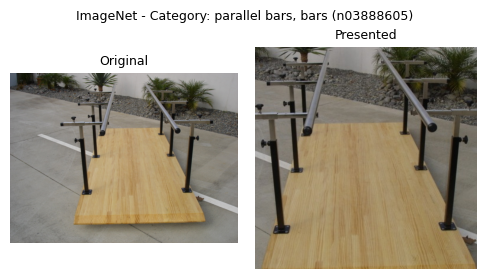

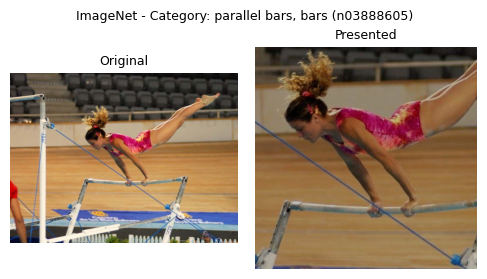

In [26]:
# Show example

# Random index of the df
random_idx = random.randint(0, len(imagenet_df) - 1)
category_id = imagenet_df.loc[random_idx, 'category_id']
category_name = imagenet_df.loc[random_idx, 'category_name']
print(f"Selected category: {category_id} → {category_name}")

# Filter the images with that category id
matching_images = [img for img in original_imagenet_images if category_id in img]

# Visualize some random images
n = min(3, len(matching_images)) # 3 images maximum
for i in range(n):
    orig_path = os.path.join(original_imagenet_images_path, matching_images[i])
    pres_path = os.path.join(presented_imagenet_images_path, matching_images[i])

    fig, axs = plt.subplots(1, 2, figsize=(5, 2.8))
    axs[0].imshow(Image.open(orig_path))
    axs[0].set_title("Original", fontsize=9)
    axs[0].axis('off')

    axs[1].imshow(Image.open(pres_path))
    axs[1].set_title("Presented", fontsize=9)
    axs[1].axis('off')

    plt.suptitle(f"ImageNet - Category: {category_name} ({category_id})", fontsize=9, y=0.98)
    plt.tight_layout()
    plt.show()

##### SUN

In [27]:
# Example of image
original_sun_images_path = os.path.join(variables.BOLD5000_PATH,'Scene_Stimuli/Original_Images/Scene')
presented_sun_images_path = os.path.join(variables.BOLD5000_PATH,'Scene_Stimuli/Presented_Stimuli/Scene')

print(f"Number of SUN images in Original_Images: {len(os.listdir(original_sun_images_path))}")
print(f"Number of SUN images in Presented_Images: {len(os.listdir(presented_sun_images_path))}")

original_sun_images = sorted(os.listdir(original_sun_images_path))
presented_sun_images = sorted(os.listdir(presented_sun_images_path))

Number of SUN images in Original_Images: 1000
Number of SUN images in Presented_Images: 1000


In [28]:
# open scene_final_labels.txt
with open(os.path.join(variables.BOLD5000_PATH,'Image_Labels/scene_final_labels.txt'), 'r') as file:
    scene_labels = [line.strip() for line in file]

print(f"Number of Scene labels: {len(scene_labels)}")
print("First 5 Scene labels:", scene_labels[:5])

Number of Scene labels: 250
First 5 Scene labels: ['readingroom', 'office', 'deck', 'promenadeDeck', 'MRI']


Image: HorseRaceTrack3.jpg - Selected category: HorseRaceTrack


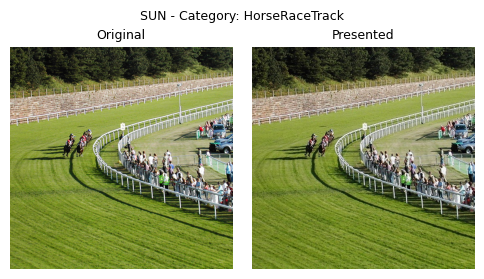

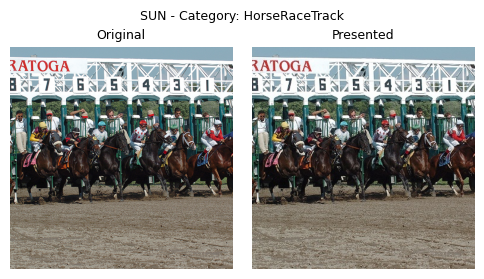

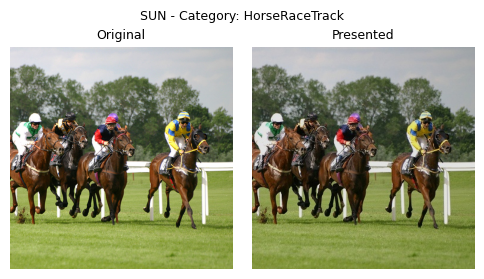

In [30]:
# Show example

# Random index of the df
random_idx = random.randint(0, len(original_sun_images) - 1)

scene_img = (os.listdir(original_sun_images_path))[random_idx]
category_name = scene_img.split(".")[0]

label = None
for lab in scene_labels:
    if lab in category_name:
        label = lab
        break
print(f"Image: {scene_img} - Selected category: {label}")

# Filter the images with that category id
matching_images = [img for img in original_sun_images if label in img]

# Visualize some random images
n = min(3, len(matching_images)) # 3 images maximum
for i in range(n):
    orig_path = os.path.join(original_sun_images_path, matching_images[i])
    pres_path = os.path.join(presented_sun_images_path, matching_images[i])

    fig, axs = plt.subplots(1, 2, figsize=(5, 2.8))
    axs[0].imshow(Image.open(orig_path))
    axs[0].set_title("Original", fontsize=9)
    axs[0].axis('off')

    axs[1].imshow(Image.open(pres_path))
    axs[1].set_title("Presented", fontsize=9)
    axs[1].axis('off')

    plt.suptitle(f"SUN - Category: {label}", fontsize=9, y=0.98)
    plt.tight_layout()
    plt.show()